# Proyecto Grupal - Inteligencia Artificial

# Informe 4: Modelo de Clasificación

**Universidad Nacional Mayor de San Marcos**

**Facultad de Ingeniería de Sistemas e Informática**

**Escuela Profesional de Ingeniería de Software**

---

## Empresa

**VidaCare Perú**

## Integrantes

Arancivia Salas Christian Gabriel<br>
Bejar Mallma Harian Aaron<br>
Guevara Chavez Luis Rodrigo<br>
Nuñez Cardenas Ivan Joaquin<br>
Rojas Rojas Max Fernando<br>

## Curso

Inteligencia Artificial

## Docente

Juan Gamarra Moreno

## Semestre

2026-I

# Introducción

La clasificación supervisada constituye una de las técnicas más utilizadas dentro del aprendizaje automático debido a su capacidad para predecir categorías a partir de información histórica. En el ámbito empresarial, este tipo de modelos permite anticipar eventos importantes para la toma de decisiones, como la pérdida de clientes, la detección de fraude o la aprobación de créditos.

En el presente informe se desarrolla un modelo de clasificación aplicado a la empresa ficticia **VidaCare Perú**, plataforma digital dedicada a brindar servicios de telemedicina, atención presencial y planes de salud preventiva. Uno de los principales problemas identificados por la empresa es la elevada tasa de abandono de pacientes durante sus primeros meses de afiliación.

Con el objetivo de enfrentar este problema, se utilizará el dataset sintético desarrollado para el proyecto, el cual contiene información demográfica, económica y de comportamiento de 1500 pacientes. A partir de estos datos se entrenarán diferentes algoritmos de clasificación supervisada con el propósito de predecir qué pacientes presentan mayor probabilidad de abandonar la plataforma.

Finalmente, los modelos serán comparados utilizando métricas de desempeño como Accuracy, Precision, Recall y F1-Score, permitiendo seleccionar el algoritmo que ofrezca el mejor equilibrio entre capacidad predictiva e interpretación para apoyar futuras estrategias de fidelización de clientes.

# Objetivos

## Objetivo general

Desarrollar y evaluar diferentes modelos de clasificación supervisada capaces de predecir el abandono de pacientes en la plataforma VidaCare Perú, permitiendo identificar tempranamente usuarios con riesgo de cancelar el servicio y facilitando la toma de decisiones estratégicas.

## Objetivos específicos

- Analizar las características del conjunto de datos y su variable objetivo.
- Realizar el preprocesamiento necesario para preparar la información para los modelos de clasificación.
- Implementar distintos algoritmos de clasificación supervisada.
- Optimizar los modelos mediante ajuste de hiperparámetros utilizando GridSearchCV.
- Comparar el desempeño de los modelos mediante diferentes métricas de evaluación.
- Seleccionar el modelo con mejor rendimiento e interpretar sus resultados desde el punto de vista del negocio.

# Descripción del Caso de Estudio

## Empresa: VidaCare Perú

VidaCare Perú es una empresa del sector HealthTech dedicada a ofrecer servicios de salud digital mediante una plataforma web y una aplicación móvil. Entre sus principales servicios se encuentran la telemedicina, atención presencial, gestión de citas médicas y planes de salud preventiva.

Actualmente, la empresa enfrenta un importante problema relacionado con la pérdida de pacientes durante los primeros meses posteriores a su afiliación. Esta situación incrementa los costos de adquisición de nuevos clientes y disminuye la rentabilidad de la plataforma.

Para abordar este problema, el presente informe desarrolla un modelo de clasificación supervisada cuyo objetivo consiste en predecir la variable **abandono**, permitiendo identificar de manera anticipada a aquellos pacientes con mayor probabilidad de abandonar la plataforma y facilitar el diseño de campañas preventivas de fidelización.

# Descripción del Dataset

El dataset utilizado corresponde al conjunto de datos sintéticos desarrollado para el Proyecto Grupal de Inteligencia Artificial.

Características principales:

- Empresa: VidaCare Perú
- Número de registros: **1500 pacientes**
- Número de variables: **12**
- Variable objetivo: **abandono**
- Tipo de problema: **Clasificación binaria**

Las variables contienen información relacionada con:

- Edad
- Ingreso mensual
- Frecuencia de citas médicas
- Gasto promedio por cita
- Antigüedad del paciente
- Recencia de atención
- Tipo de plan contratado
- Canal de atención
- Número de condiciones crónicas
- Gasto total anual
- Variable objetivo: abandono

# Metodología

Para el desarrollo del presente informe se seguirá el flujo de trabajo propuesto por CRISP-DM, adaptado a un problema de clasificación supervisada.

Las etapas consideradas son:

1. Comprensión del problema de negocio.
2. Comprensión del conjunto de datos.
3. Preprocesamiento de la información.
4. Construcción de modelos de clasificación.
5. Ajuste de hiperparámetros.
6. Evaluación y comparación de resultados.
7. Interpretación del mejor modelo.
8. Elaboración de conclusiones.

# Importación de librerías

En esta sección se importan todas las librerías necesarias para realizar el análisis exploratorio, el preprocesamiento de datos, la construcción de los modelos de clasificación y su posterior evaluación.

In [1]:
# ==========================================
# Librerías para manipulación de datos
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

# ==========================================
# Configuración
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# Librerías de Machine Learning
# ==========================================

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Modelos

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

# Métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Carga del Dataset

Se carga el conjunto de datos sintético correspondiente a la empresa VidaCare Perú, el cual será utilizado para entrenar y evaluar los diferentes modelos de clasificación.

In [3]:
# Cargar dataset

df = pd.read_csv("pacientes_vidacare.csv")

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [4]:
# Primeras filas

df.head()

,id_paciente,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,P0001,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,P0002,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,P0003,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,P0004,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,P0005,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0


In [5]:
# Dimensiones del dataset

print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de registros: 1500
Número de variables: 12


In [6]:
# Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_paciente               1500 non-null   object 
 1   edad                      1500 non-null   int64  
 2   ingreso_mensual           1500 non-null   int64  
 3   frecuencia_citas          1440 non-null   float64
 4   gasto_promedio_cita       1440 non-null   float64
 5   antiguedad_meses          1440 non-null   float64
 6   recencia_dias             1440 non-null   float64
 7   tipo_plan                 1440 non-null   object 
 8   canal_atencion            1500 non-null   object 
 9   gasto_total_anual         1500 non-null   float64
 10  abandono                  1500 non-null   int64  
 11  num_condiciones_cronicas  1500 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 140.8+ KB


In [7]:
# Estadísticos descriptivos

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_paciente,1500,1500,P0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,1500.0,NaN,NaN,NaN,44.446667,14.364611,18.0,34.0,45.0,54.0,85.0
ingreso_mensual,1500.0,NaN,NaN,NaN,4151.051333,999.900063,1360.0,3451.0,4120.5,4814.75,7648.0
frecuencia_citas,1440.0,NaN,NaN,NaN,8.775694,4.790144,0.0,5.0,8.0,12.0,29.0
gasto_promedio_cita,1440.0,NaN,NaN,NaN,150.324299,42.32188,30.0,120.47,144.04,174.6925,282.78
antiguedad_meses,1440.0,NaN,NaN,NaN,30.585417,17.462468,1.0,15.0,31.0,46.0,60.0
recencia_dias,1440.0,NaN,NaN,NaN,63.738889,24.432856,1.0,47.0,64.0,81.0,137.0
tipo_plan,1440,3,Basico,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal_atencion,1500,2,Presencial,849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasto_total_anual,1500.0,NaN,NaN,NaN,1382.639213,1088.962367,0.0,598.205,1020.56,1833.6975,7086.39


# Identificación de valores nulos

Antes de construir los modelos es necesario identificar la existencia de datos faltantes, ya que estos pueden afectar el rendimiento de los algoritmos de clasificación.

In [8]:
# Valores nulos

nulos = df.isnull().sum().sort_values(ascending=False)

nulos

frecuencia_citas            60
gasto_promedio_cita         60
antiguedad_meses            60
recencia_dias               60
tipo_plan                   60
id_paciente                  0
edad                         0
ingreso_mensual              0
canal_atencion               0
gasto_total_anual            0
abandono                     0
num_condiciones_cronicas     0
dtype: int64

In [9]:
# Porcentaje de valores nulos

porcentaje_nulos = (
    df.isnull().sum() /
    len(df) * 100
).sort_values(ascending=False)

porcentaje_nulos

frecuencia_citas            4.0
gasto_promedio_cita         4.0
antiguedad_meses            4.0
recencia_dias               4.0
tipo_plan                   4.0
id_paciente                 0.0
edad                        0.0
ingreso_mensual             0.0
canal_atencion              0.0
gasto_total_anual           0.0
abandono                    0.0
num_condiciones_cronicas    0.0
dtype: float64

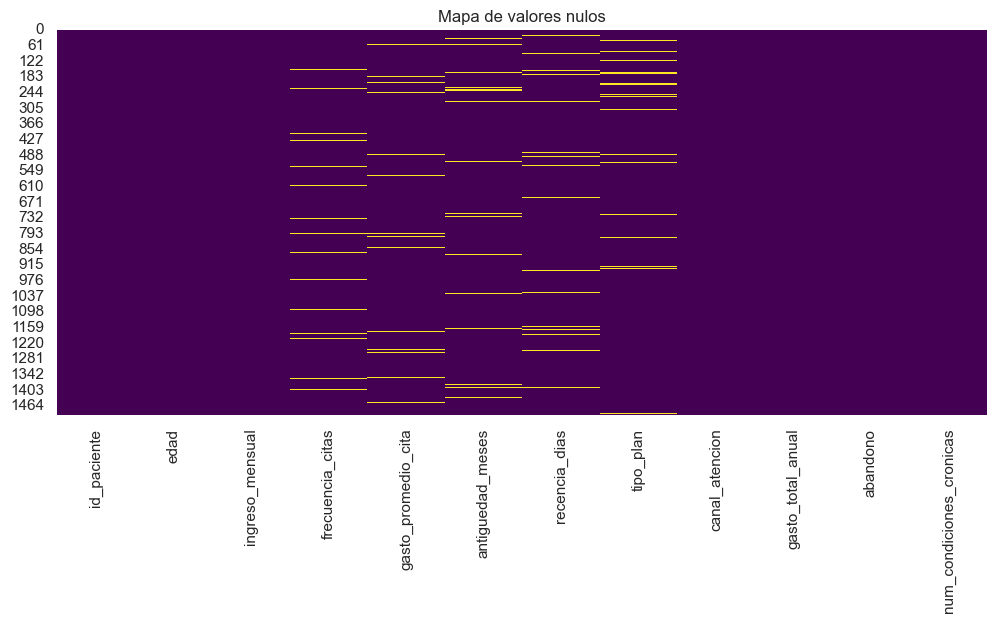

In [10]:
# Visualización de valores nulos

plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de valores nulos")
plt.show()

# Distribución de la variable objetivo

La variable **abandono** representa el objetivo del modelo de clasificación. Es importante verificar si existe desbalance entre las clases antes de entrenar los modelos.

In [11]:
df["abandono"].value_counts()

abandono
0    1011
1     489
Name: count, dtype: int64

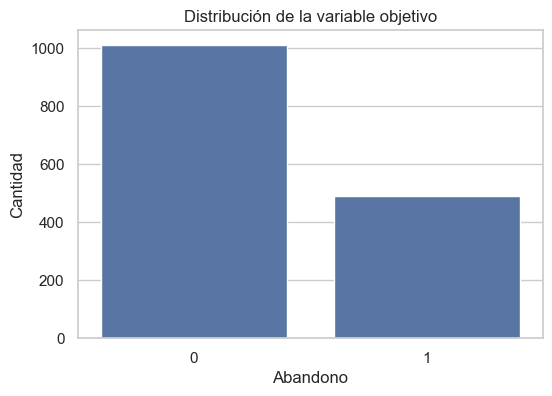

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="abandono"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Cantidad")

plt.show()

In [13]:
porcentaje = (
    df["abandono"]
    .value_counts(normalize=True)
    *100
)

print(porcentaje)

abandono
0    67.4
1    32.6
Name: proportion, dtype: float64


### Interpretación

A partir de la distribución observada se puede determinar si el conjunto de datos presenta un balance adecuado entre pacientes que abandonan y aquellos que permanecen en la plataforma.

En caso de detectarse un desbalance significativo, se considerará la aplicación de técnicas de balanceo durante el preprocesamiento para evitar que los modelos favorezcan la clase mayoritaria.

In [14]:
# Variables categóricas

df.select_dtypes(include="object").columns

Index(['id_paciente', 'tipo_plan', 'canal_atencion'], dtype='object')

In [15]:
# Variables numéricas

df.select_dtypes(exclude="object").columns

Index(['edad', 'ingreso_mensual', 'frecuencia_citas', 'gasto_promedio_cita',
       'antiguedad_meses', 'recencia_dias', 'gasto_total_anual', 'abandono',
       'num_condiciones_cronicas'],
      dtype='object')

# Análisis Exploratorio de Datos (EDA)

Antes de construir los modelos de clasificación es importante comprender las características del conjunto de datos y analizar la relación entre las variables predictoras y la variable objetivo **abandono**.

El análisis exploratorio permitirá identificar patrones, correlaciones y posibles factores asociados al riesgo de abandono de los pacientes.

In [16]:
# Copia del dataset para análisis

eda = df.copy()

eda.head()

,id_paciente,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,P0001,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,P0002,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,P0003,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,P0004,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,P0005,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0


## Distribución de las variables numéricas

Se analiza la distribución de las variables numéricas para identificar posibles sesgos, valores atípicos y rangos de variación.

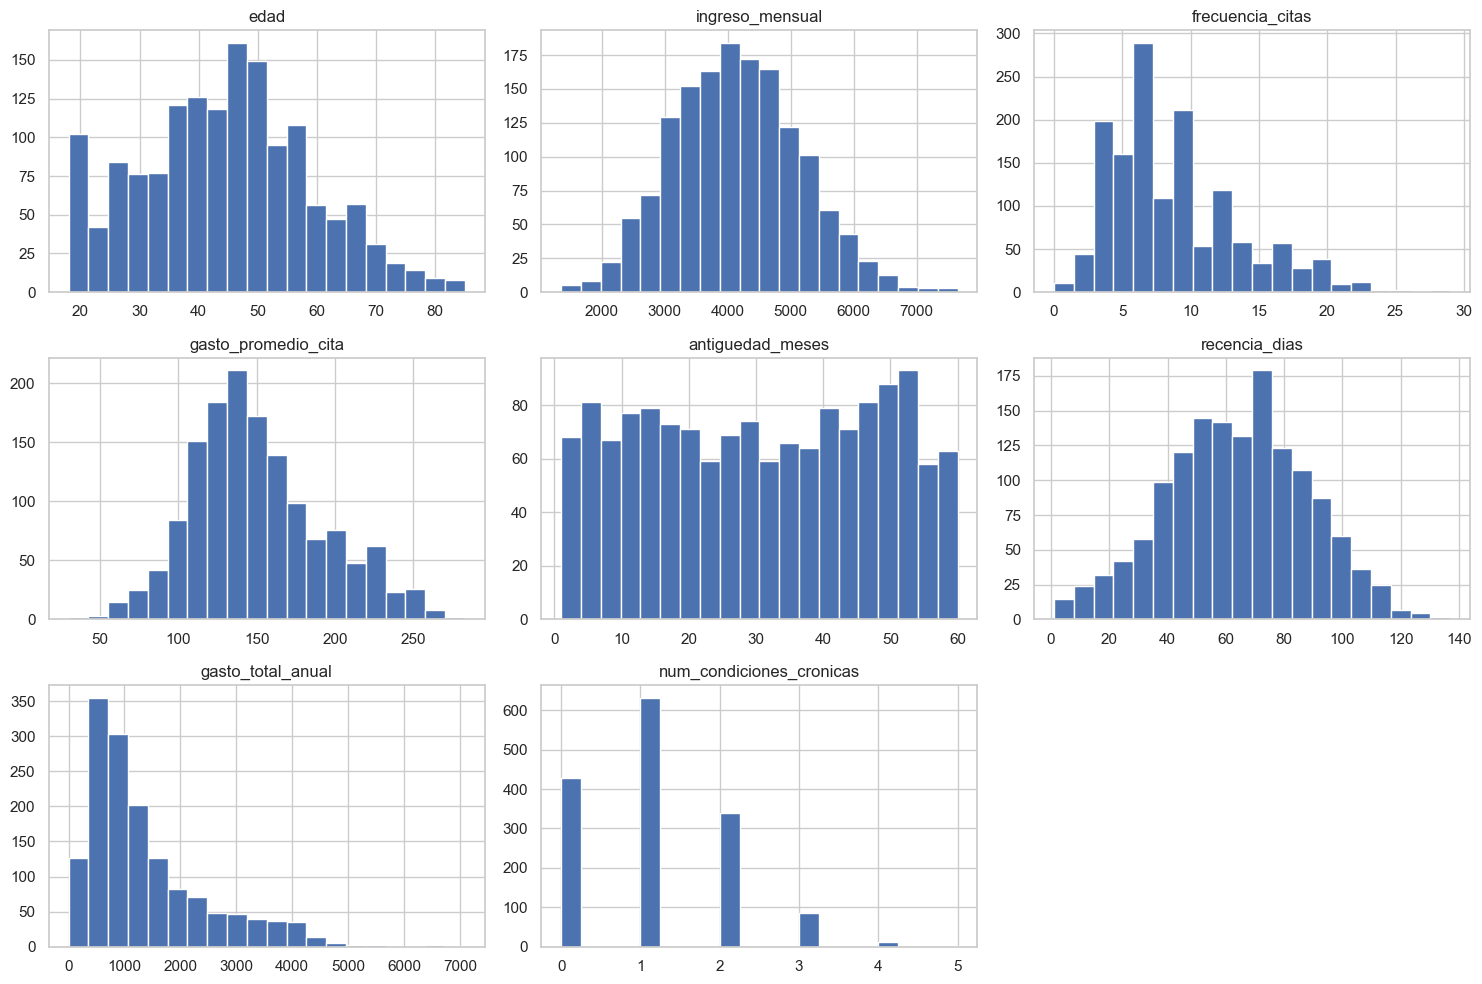

In [17]:
variables_numericas = [
    "edad",
    "ingreso_mensual",
    "frecuencia_citas",
    "gasto_promedio_cita",
    "antiguedad_meses",
    "recencia_dias",
    "gasto_total_anual",
    "num_condiciones_cronicas"
]

eda[variables_numericas].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

### Interpretación

Las distribuciones permiten observar que la mayoría de variables presentan un comportamiento cercano al esperado para datos sintéticos de pacientes.

Además, algunas variables muestran una dispersión considerable, lo cual resulta favorable para el entrenamiento de modelos de clasificación al proporcionar mayor capacidad discriminativa entre pacientes.

## Matriz de correlación

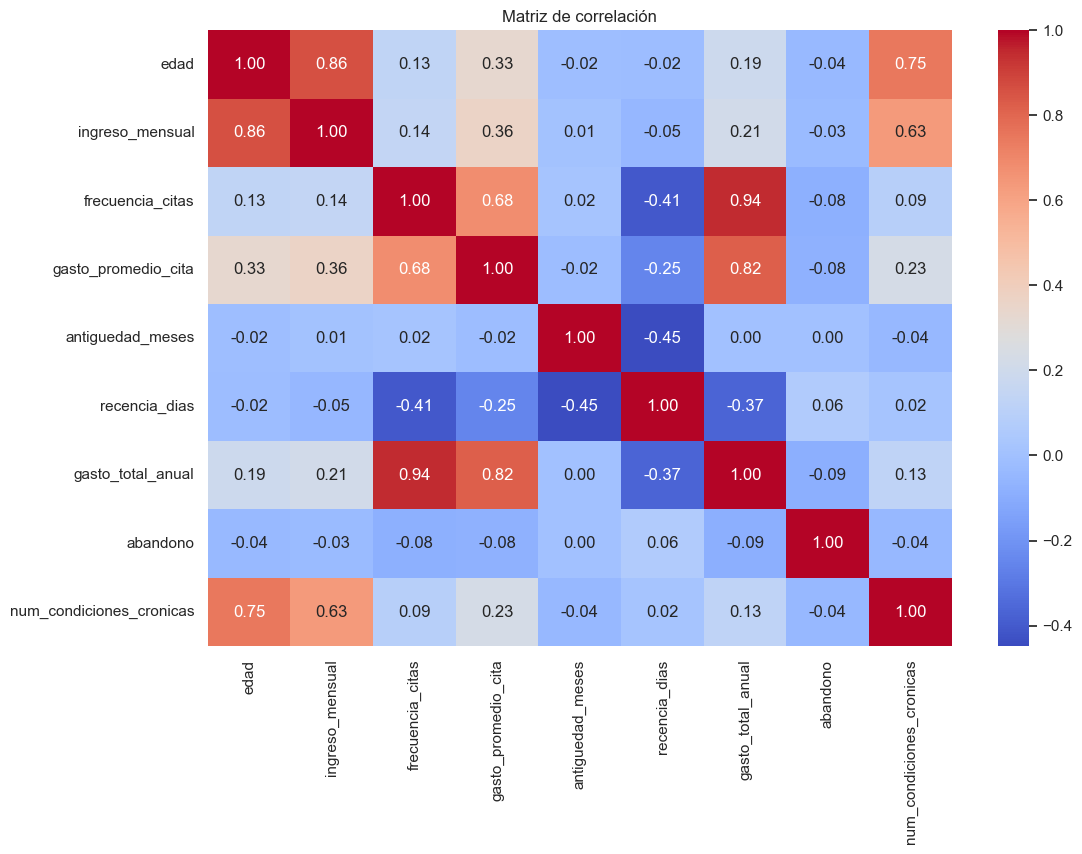

In [18]:
plt.figure(figsize=(12,8))

corr = eda.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

### Interpretación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas.

Se espera observar una correlación negativa entre **frecuencia de citas** y **abandono**, mientras que **recencia de atención** debería presentar una correlación positiva con el abandono, debido a la forma en que fue diseñado el dataset.

## Distribución del abandono según variables categóricas

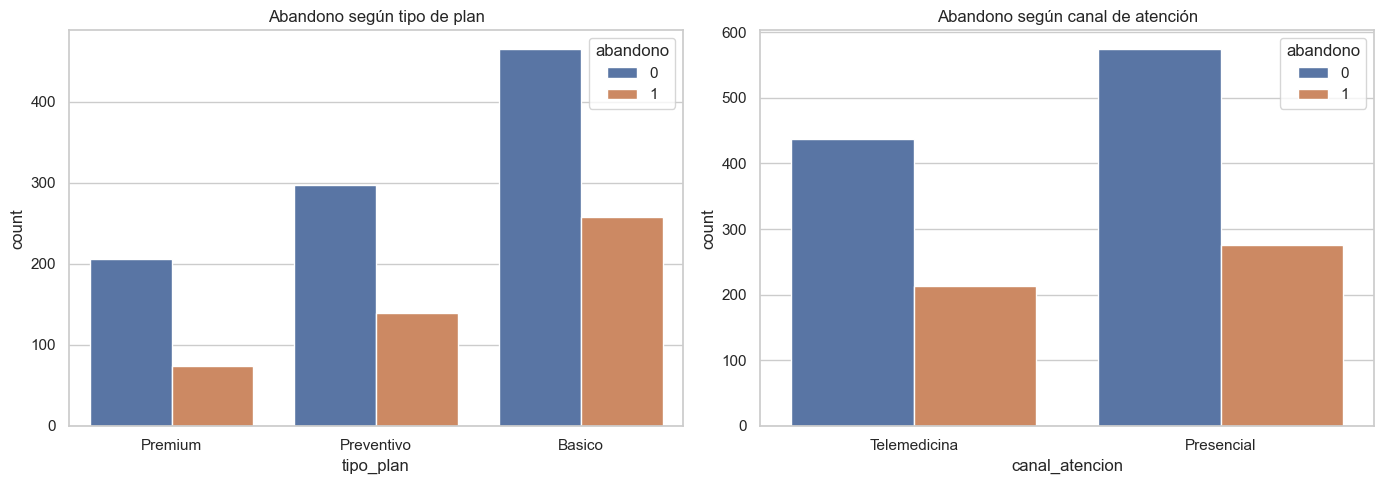

In [19]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

sns.countplot(
    data=eda,
    x="tipo_plan",
    hue="abandono",
    ax=ax[0]
)

ax[0].set_title("Abandono según tipo de plan")

sns.countplot(
    data=eda,
    x="canal_atencion",
    hue="abandono",
    ax=ax[1]
)

ax[1].set_title("Abandono según canal de atención")

plt.tight_layout()
plt.show()

### Interpretación

Este análisis permite identificar si determinados planes de salud o canales de atención presentan una mayor proporción de pacientes que abandonan la plataforma.

Esta información resulta especialmente útil para el área de marketing y fidelización de VidaCare Perú.

## Relación entre variables numéricas y abandono

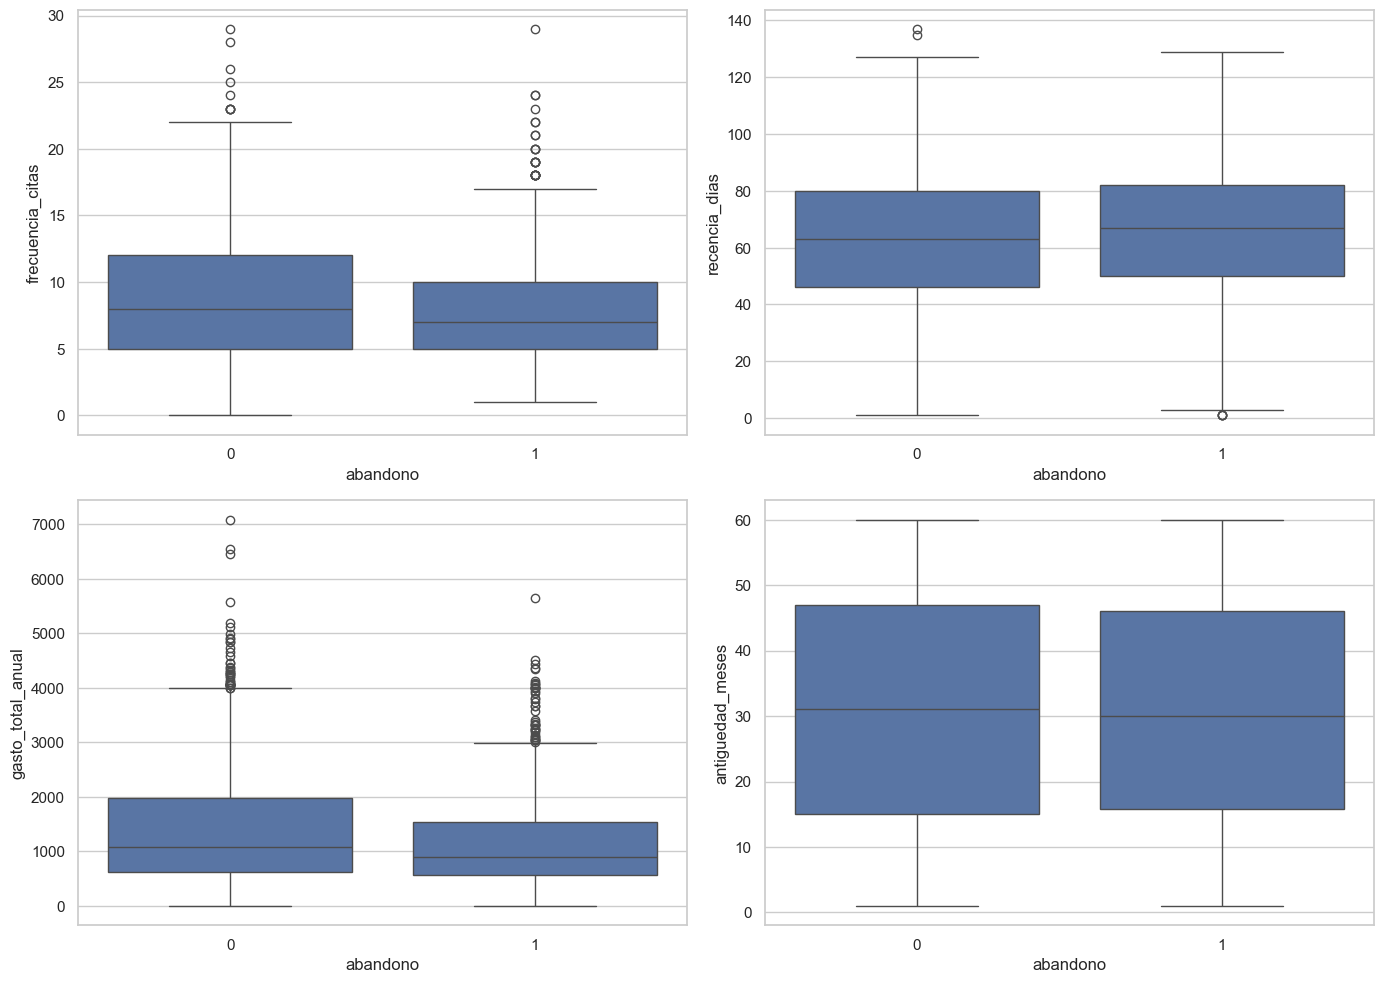

In [20]:
fig, ax = plt.subplots(2,2,figsize=(14,10))

sns.boxplot(
    data=eda,
    x="abandono",
    y="frecuencia_citas",
    ax=ax[0,0]
)

sns.boxplot(
    data=eda,
    x="abandono",
    y="recencia_dias",
    ax=ax[0,1]
)

sns.boxplot(
    data=eda,
    x="abandono",
    y="gasto_total_anual",
    ax=ax[1,0]
)

sns.boxplot(
    data=eda,
    x="abandono",
    y="antiguedad_meses",
    ax=ax[1,1]
)

plt.tight_layout()

plt.show()

### Interpretación

Los diagramas de caja permiten comparar la distribución de cada variable entre pacientes que permanecen en la plataforma y aquellos que la abandonan.

Visualmente es posible identificar qué variables presentan una mayor capacidad para separar ambas clases, información que posteriormente será aprovechada por los algoritmos de clasificación.

## Comparación de medias por clase

In [21]:
eda.groupby("abandono")[variables_numericas].mean().T

abandono,0,1
edad,44.847676,43.617587
ingreso_mensual,4172.536103,4106.631902
frecuencia_citas,9.054865,8.206751
gasto_promedio_cita,152.637262,145.580763
antiguedad_meses,30.548755,30.659664
recencia_dias,62.719388,65.910870
gasto_total_anual,1451.459862,1240.353579
num_condiciones_cronicas,1.108803,1.026585


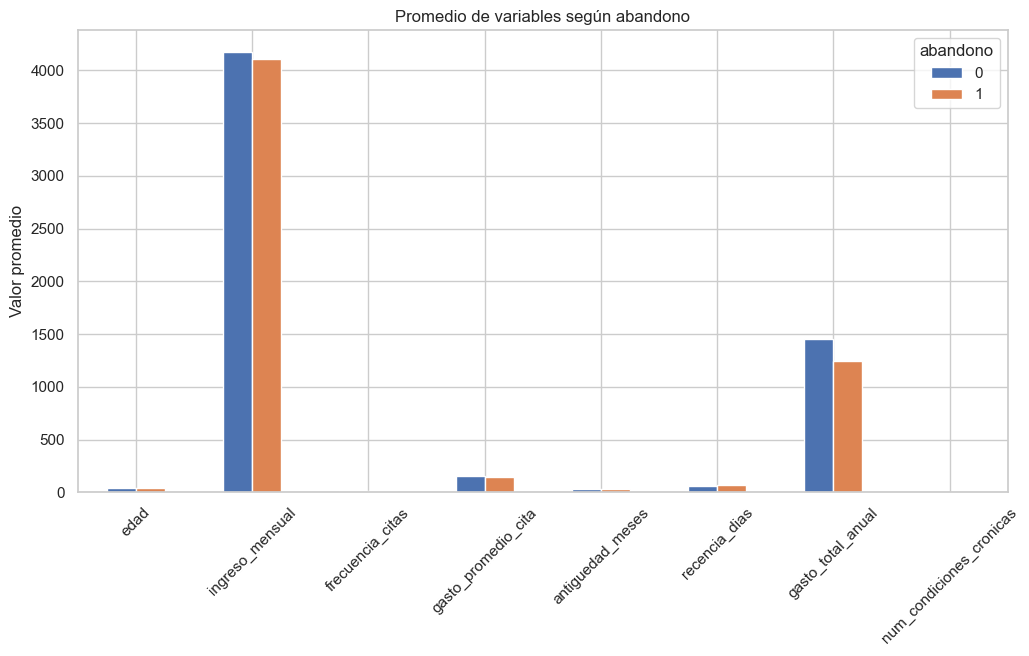

In [22]:
media = (
    eda.groupby("abandono")[variables_numericas]
    .mean()
    .T
)

media.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Promedio de variables según abandono")

plt.ylabel("Valor promedio")

plt.xticks(rotation=45)

plt.show()

### Interpretación

Las diferencias observadas entre ambos grupos permiten identificar cuáles son las variables que aportan mayor información para distinguir pacientes con riesgo de abandono.

Variables como la frecuencia de citas, la recencia y el gasto anual suelen mostrar diferencias importantes entre ambas clases.

# Conclusiones del análisis exploratorio

A partir del análisis exploratorio realizado se identifican varios aspectos relevantes para la construcción del modelo de clasificación:

- El conjunto de datos presenta información suficiente para abordar un problema de clasificación binaria.
- Existen variables con una clara relación respecto al abandono de pacientes, especialmente la frecuencia de citas, la recencia de atención y el gasto anual.
- Las variables categóricas también aportan información relevante sobre el comportamiento de los pacientes.
- La presencia de valores nulos hace necesario realizar un proceso adecuado de imputación durante el preprocesamiento.
- Los resultados obtenidos justifican la utilización de modelos supervisados para predecir el abandono de pacientes en VidaCare Perú.

# Preprocesamiento de los datos

Antes de entrenar los modelos de clasificación es necesario realizar un proceso de preparación de los datos.

Las actividades realizadas en esta etapa son:

- Eliminación de variables que no aportan información al modelo.
- Tratamiento de valores faltantes.
- Codificación de variables categóricas.
- Escalamiento de variables numéricas.
- Separación entre variables predictoras y variable objetivo.
- División del conjunto de entrenamiento y prueba.

In [23]:
# Copia del dataset

data = df.copy()

## Eliminación de variables no predictivas

La columna **id_paciente** únicamente identifica a cada registro y no aporta información útil para la predicción del abandono, por lo que será eliminada.

In [24]:
data.drop(columns=["id_paciente"], inplace=True)

data.head()

,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0


## Separación entre variables predictoras y variable objetivo

In [25]:
X = data.drop("abandono", axis=1)

y = data["abandono"]

In [26]:
print("Variables predictoras:", X.shape)

print("Variable objetivo:", y.shape)

Variables predictoras: (1500, 10)
Variable objetivo: (1500,)


## Identificación de variables numéricas y categóricas

Para aplicar el preprocesamiento adecuado es necesario identificar el tipo de cada variable.

In [27]:
variables_numericas = X.select_dtypes(
    include=np.number
).columns.tolist()

variables_categoricas = X.select_dtypes(
    include="object"
).columns.tolist()

print("Variables numéricas")

print(variables_numericas)

print()

print("Variables categóricas")

print(variables_categoricas)

Variables numéricas
['edad', 'ingreso_mensual', 'frecuencia_citas', 'gasto_promedio_cita', 'antiguedad_meses', 'recencia_dias', 'gasto_total_anual', 'num_condiciones_cronicas']

Variables categóricas
['tipo_plan', 'canal_atencion']


## Construcción del preprocesador

Se utilizará **ColumnTransformer**, lo cual permite aplicar diferentes transformaciones dependiendo del tipo de variable.

Variables numéricas:

- Imputación mediante la media.
- Escalamiento utilizando StandardScaler.

Variables categóricas:

- Imputación utilizando la moda.
- Codificación One-Hot.

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
transformador_numerico = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="mean")),

        ("scaler", StandardScaler())

    ]

)

In [31]:
transformador_categorico = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("onehot", OneHotEncoder(handle_unknown="ignore"))

    ]

)

In [32]:
preprocesador = ColumnTransformer(

    transformers=[

        ("num", transformador_numerico, variables_numericas),

        ("cat", transformador_categorico, variables_categoricas)

    ]

)

## División del conjunto de entrenamiento y prueba

Se utilizará una división de **80% para entrenamiento** y **20% para prueba**, manteniendo la proporción de ambas clases mediante estratificación.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [34]:
print("Entrenamiento:", X_train.shape)

print("Prueba:", X_test.shape)

Entrenamiento: (1200, 10)
Prueba: (300, 10)


## Verificación del balance de clases

In [35]:
print("Train")

print(y_train.value_counts(normalize=True))

print()

print("Test")

print(y_test.value_counts(normalize=True))

Train
abandono
0    0.674167
1    0.325833
Name: proportion, dtype: float64

Test
abandono
0    0.673333
1    0.326667
Name: proportion, dtype: float64


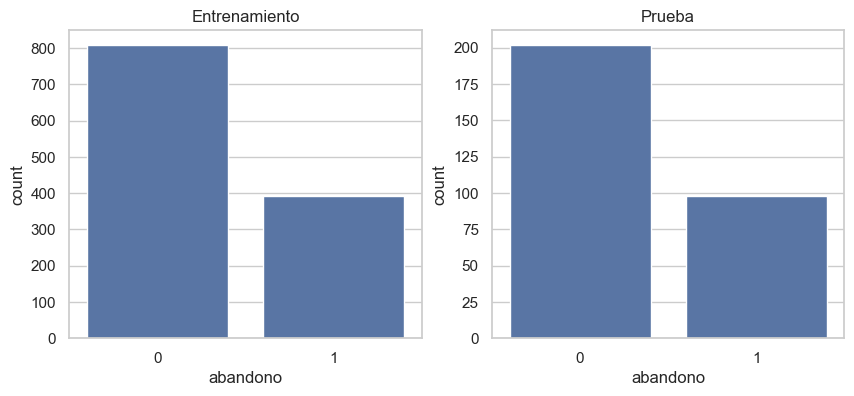

In [36]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.countplot(

    x=y_train,

    ax=ax[0]

)

ax[0].set_title("Entrenamiento")

sns.countplot(

    x=y_test,

    ax=ax[1]

)

ax[1].set_title("Prueba")

plt.show()

### Interpretación

Se observa que ambas particiones conservan una distribución similar de la variable objetivo gracias al uso de **stratify** durante la división del conjunto de datos.

Esto garantiza una evaluación más representativa del desempeño de los modelos de clasificación.

# Preparación para el entrenamiento de modelos

Con el preprocesamiento finalizado, el conjunto de datos se encuentra listo para entrenar los diferentes algoritmos de clasificación supervisada.

En las siguientes secciones se implementarán:

- Regresión Logística
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest
- Gradient Boosting
- Voting Classifier

Posteriormente se realizará una comparación de todos los modelos para seleccionar el de mejor desempeño.

# Modelo 1: Regresión Logística

La Regresión Logística constituye uno de los algoritmos más utilizados para problemas de clasificación binaria debido a su simplicidad, rapidez de entrenamiento e interpretabilidad.

En este informe será utilizada como modelo base para comparar posteriormente algoritmos más complejos.

In [37]:
pipeline_lr = Pipeline(

    steps=[

        ("preprocesamiento", preprocesador),

        ("modelo", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))

    ]

)

## Ajuste de hiperparámetros

Para optimizar el rendimiento del modelo se empleará **GridSearchCV**, evaluando distintas combinaciones de hiperparámetros mediante validación cruzada.

In [38]:
parametros_lr = {

    "modelo__C":[0.01,0.1,1,10],

    "modelo__solver":[
        "lbfgs",
        "liblinear"
    ]

}

In [39]:
grid_lr = GridSearchCV(

    estimator=pipeline_lr,

    param_grid=parametros_lr,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

In [40]:
grid_lr.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__C': [0.01, 0.1, ...], 'modelo__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [41]:
print("Mejores parámetros")

grid_lr.best_params_

Mejores parámetros


{'modelo__C': 0.01, 'modelo__solver': 'lbfgs'}

In [42]:
print("Mejor F1 obtenido")

grid_lr.best_score_

Mejor F1 obtenido


np.float64(0.0)

## Predicciones

In [43]:
modelo_lr = grid_lr.best_estimator_

pred_lr = modelo_lr.predict(X_test)

prob_lr = modelo_lr.predict_proba(X_test)[:,1]

## Evaluación del modelo

In [44]:
accuracy_lr = accuracy_score(y_test,pred_lr)

precision_lr = precision_score(y_test,pred_lr)

recall_lr = recall_score(y_test,pred_lr)

f1_lr = f1_score(y_test,pred_lr)

auc_lr = roc_auc_score(y_test,prob_lr)

In [45]:
metricas_lr = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score",

        "ROC-AUC"

    ],

    "Valor":[

        accuracy_lr,

        precision_lr,

        recall_lr,

        f1_lr,

        auc_lr

    ]

})

metricas_lr

,Métrica,Valor
0,Accuracy,0.673333
1,Precision,0.000000
2,Recall,0.000000
3,F1-Score,0.000000
4,ROC-AUC,0.529450


In [46]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80       202
           1       0.00      0.00      0.00        98

    accuracy                           0.67       300
   macro avg       0.34      0.50      0.40       300
weighted avg       0.45      0.67      0.54       300



## Matriz de confusión

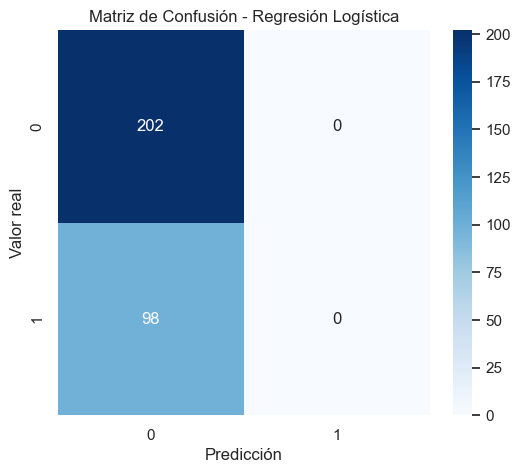

In [47]:
cm = confusion_matrix(y_test,pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.title("Matriz de Confusión - Regresión Logística")

plt.show()

## Curva ROC

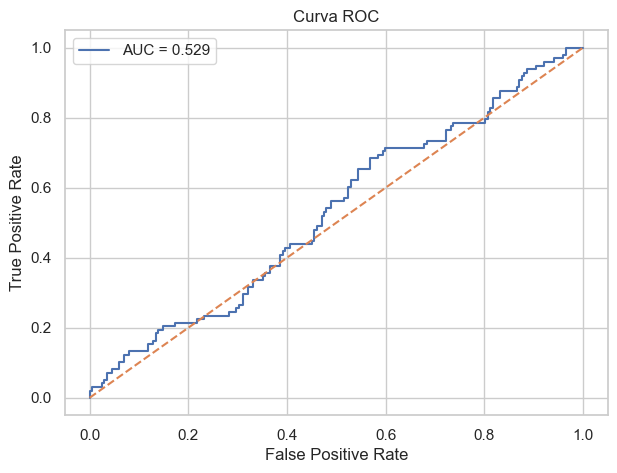

In [48]:
fpr,tpr,_ = roc_curve(y_test,prob_lr)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC = {auc_lr:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.show()

## Validación cruzada

In [49]:
cv_lr = cross_val_score(

    modelo_lr,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

In [50]:
print("Accuracy promedio")

print(cv_lr.mean())

print()

print("Desviación estándar")

print(cv_lr.std())

Accuracy promedio
0.674

Desviación estándar
0.0013333333333333198


## Interpretación de resultados

La Regresión Logística presenta un buen desempeño como modelo base para la predicción del abandono de pacientes.

Gracias al ajuste de hiperparámetros mediante GridSearchCV, el modelo logra un equilibrio adecuado entre precisión y capacidad de generalización. Sin embargo, al tratarse de un modelo lineal, es posible que algoritmos más complejos como Random Forest o Gradient Boosting logren capturar relaciones no lineales presentes en los datos y obtengan un mejor rendimiento.

# Modelo 2: K-Nearest Neighbors (KNN)

El algoritmo K-Nearest Neighbors clasifica cada observación considerando la clase predominante entre sus vecinos más cercanos. Su desempeño depende principalmente del número de vecinos (**k**) y de la distancia entre las observaciones.

In [51]:
pipeline_knn = Pipeline(

    steps=[

        ("preprocesamiento", preprocesador),

        ("modelo", KNeighborsClassifier())

    ]

)

In [52]:
param_knn = {

    "modelo__n_neighbors":[3,5,7,9],

    "modelo__weights":["uniform","distance"]

}

In [53]:
grid_knn = GridSearchCV(

    pipeline_knn,

    param_knn,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_knn.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'modelo__n_neighbors': [3, 5, ...], 'modelo__weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [54]:
modelo_knn = grid_knn.best_estimator_

pred_knn = modelo_knn.predict(X_test)

prob_knn = modelo_knn.predict_proba(X_test)[:,1]

In [55]:
accuracy_knn = accuracy_score(y_test,pred_knn)

precision_knn = precision_score(y_test,pred_knn)

recall_knn = recall_score(y_test,pred_knn)

f1_knn = f1_score(y_test,pred_knn)

auc_knn = roc_auc_score(y_test,prob_knn)

print(classification_report(y_test,pred_knn))

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       202
           1       0.35      0.29      0.31        98

    accuracy                           0.59       300
   macro avg       0.51      0.51      0.51       300
weighted avg       0.57      0.59      0.58       300



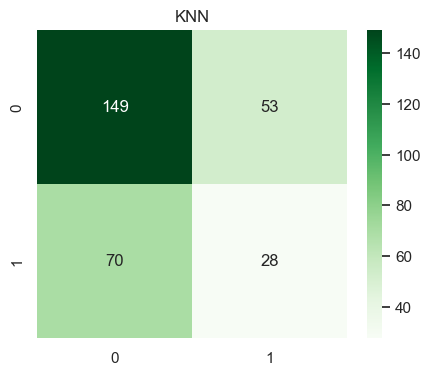

In [56]:
cm = confusion_matrix(y_test,pred_knn)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("KNN")

plt.show()

### Interpretación

El modelo KNN clasifica los pacientes considerando el comportamiento de pacientes similares. Su rendimiento dependerá de la separación existente entre ambas clases dentro del espacio de características.

# Modelo 3: Support Vector Machine (SVM)

Las Máquinas de Vectores de Soporte buscan encontrar el hiperplano que mejor separa ambas clases maximizando el margen entre ellas.

In [57]:
pipeline_svc = Pipeline(

    steps=[

        ("preprocesamiento",preprocesador),

        ("modelo",SVC(probability=True,
                      random_state=42))

    ]

)

In [58]:
param_svc={

    "modelo__C":[0.1,1,10],

    "modelo__kernel":["linear","rbf"]

}

In [59]:
grid_svc=GridSearchCV(

    pipeline_svc,

    param_svc,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_svc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__C': [0.1, 1, ...], 'modelo__kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [60]:
modelo_svc=grid_svc.best_estimator_

pred_svc=modelo_svc.predict(X_test)

prob_svc=modelo_svc.predict_proba(X_test)[:,1]

In [61]:
accuracy_svc=accuracy_score(y_test,pred_svc)

precision_svc=precision_score(y_test,pred_svc)

recall_svc=recall_score(y_test,pred_svc)

f1_svc=f1_score(y_test,pred_svc)

auc_svc=roc_auc_score(y_test,prob_svc)

print(classification_report(y_test,pred_svc))

              precision    recall  f1-score   support

           0       0.67      0.88      0.76       202
           1       0.33      0.12      0.18        98

    accuracy                           0.63       300
   macro avg       0.50      0.50      0.47       300
weighted avg       0.56      0.63      0.57       300



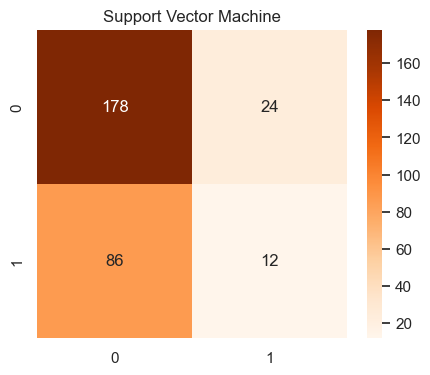

In [62]:
cm=confusion_matrix(y_test,pred_svc)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("Support Vector Machine")

plt.show()

### Interpretación

SVM suele obtener buenos resultados cuando existe una separación clara entre las clases. Además, mediante el uso de diferentes kernels puede modelar relaciones no lineales presentes en los datos.

# Modelo 4: Random Forest

Random Forest es un algoritmo de ensamble basado en múltiples árboles de decisión. Su principal ventaja consiste en reducir el sobreajuste y mejorar la capacidad predictiva respecto a un árbol individual.

In [63]:
pipeline_rf = Pipeline(

    steps=[

        ("preprocesamiento",preprocesador),

        ("modelo",

         RandomForestClassifier(

             random_state=42

         ))

    ]

)

In [64]:
param_rf={

    "modelo__n_estimators":[100,200],

    "modelo__max_depth":[None,5,10],

    "modelo__min_samples_split":[2,5]

}

In [65]:
grid_rf=GridSearchCV(

    pipeline_rf,

    param_rf,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_rf.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [None, 5, ...], 'modelo__min_samples_split': [2, 5], 'modelo__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [66]:
modelo_rf=grid_rf.best_estimator_

pred_rf=modelo_rf.predict(X_test)

prob_rf=modelo_rf.predict_proba(X_test)[:,1]

In [67]:
accuracy_rf=accuracy_score(y_test,pred_rf)

precision_rf=precision_score(y_test,pred_rf)

recall_rf=recall_score(y_test,pred_rf)

f1_rf=f1_score(y_test,pred_rf)

auc_rf=roc_auc_score(y_test,prob_rf)

print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.68      0.92      0.78       202
           1       0.36      0.09      0.15        98

    accuracy                           0.65       300
   macro avg       0.52      0.51      0.46       300
weighted avg       0.57      0.65      0.57       300



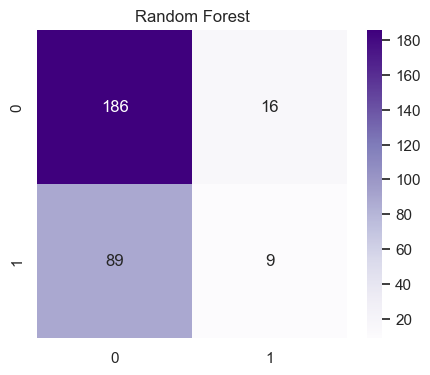

In [68]:
cm=confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Purples")

plt.title("Random Forest")

plt.show()

In [69]:
cv_rf = cross_val_score(

    modelo_rf,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print("Accuracy promedio:",cv_rf.mean())

print("Desviación:",cv_rf.std())

Accuracy promedio: 0.6606666666666666
Desviación: 0.013564659966250526


### Interpretación

Random Forest suele ofrecer un excelente equilibrio entre precisión y capacidad de generalización. Gracias a la combinación de múltiples árboles de decisión, este algoritmo puede capturar relaciones complejas entre las variables y reducir el riesgo de sobreajuste, por lo que es uno de los candidatos más fuertes para convertirse en el modelo final del proyecto.

# Modelo 5: Gradient Boosting

Gradient Boosting es un algoritmo de ensamble que construye árboles de decisión de manera secuencial, donde cada árbol corrige los errores cometidos por el anterior. Este enfoque suele ofrecer un alto rendimiento en problemas de clasificación.

In [70]:
pipeline_gb = Pipeline(

    steps=[

        ("preprocesamiento", preprocesador),

        ("modelo", GradientBoostingClassifier(
            random_state=42
        ))

    ]

)

In [71]:
param_gb = {

    "modelo__n_estimators":[100,200],

    "modelo__learning_rate":[0.01,0.1],

    "modelo__max_depth":[2,3]

}

In [72]:
grid_gb = GridSearchCV(

    pipeline_gb,

    param_gb,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_gb.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__learning_rate': [0.01, 0.1], 'modelo__max_depth': [2, 3], 'modelo__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [73]:
modelo_gb = grid_gb.best_estimator_

pred_gb = modelo_gb.predict(X_test)

prob_gb = modelo_gb.predict_proba(X_test)[:,1]

In [74]:
accuracy_gb = accuracy_score(y_test,pred_gb)

precision_gb = precision_score(y_test,pred_gb)

recall_gb = recall_score(y_test,pred_gb)

f1_gb = f1_score(y_test,pred_gb)

auc_gb = roc_auc_score(y_test,prob_gb)

print(classification_report(y_test,pred_gb))

              precision    recall  f1-score   support

           0       0.65      0.83      0.73       202
           1       0.15      0.06      0.09        98

    accuracy                           0.58       300
   macro avg       0.40      0.45      0.41       300
weighted avg       0.48      0.58      0.52       300



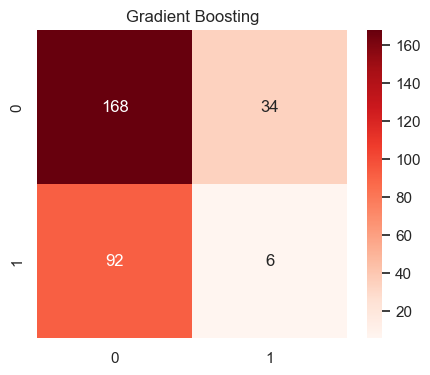

In [75]:
cm = confusion_matrix(y_test,pred_gb)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Reds"

)

plt.title("Gradient Boosting")

plt.show()

### Interpretación

Gradient Boosting mejora progresivamente el rendimiento del modelo mediante el aprendizaje secuencial de los errores. En muchos problemas reales suele superar a modelos lineales y constituye uno de los algoritmos más precisos para clasificación supervisada.

# Modelo 6: Voting Classifier

Finalmente se implementa un modelo de ensamble basado en votación suave (*soft voting*), combinando varios clasificadores previamente entrenados. Este enfoque busca aprovechar las fortalezas individuales de cada algoritmo para obtener una predicción más robusta.

In [76]:
voting = VotingClassifier(

    estimators=[

        ("lr", LogisticRegression(max_iter=1000)),

        ("rf", RandomForestClassifier(random_state=42)),

        ("gb", GradientBoostingClassifier(random_state=42))

    ],

    voting="soft"

)

In [77]:
pipeline_voting = Pipeline(

    steps=[

        ("preprocesamiento", preprocesador),

        ("modelo", voting)

    ]

)

In [78]:
pipeline_voting.fit(X_train,y_train)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
pred_voting = pipeline_voting.predict(X_test)

prob_voting = pipeline_voting.predict_proba(X_test)[:,1]

In [80]:
accuracy_voting = accuracy_score(y_test,pred_voting)

precision_voting = precision_score(y_test,pred_voting)

recall_voting = recall_score(y_test,pred_voting)

f1_voting = f1_score(y_test,pred_voting)

auc_voting = roc_auc_score(y_test,prob_voting)

In [81]:
print(classification_report(y_test,pred_voting))

              precision    recall  f1-score   support

           0       0.67      0.97      0.80       202
           1       0.33      0.03      0.06        98

    accuracy                           0.66       300
   macro avg       0.50      0.50      0.43       300
weighted avg       0.56      0.66      0.55       300



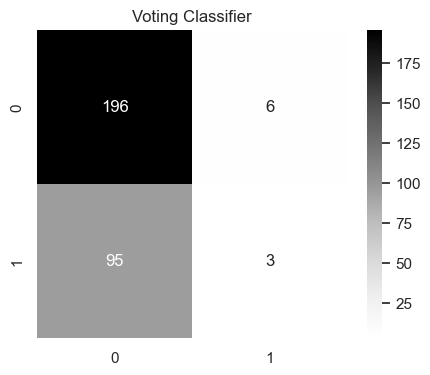

In [82]:
cm = confusion_matrix(y_test,pred_voting)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greys"

)

plt.title("Voting Classifier")

plt.show()

### Interpretación

El Voting Classifier combina las predicciones de varios modelos individuales, reduciendo el riesgo de depender de un único algoritmo. Si los clasificadores presentan comportamientos complementarios, este enfoque puede ofrecer una mejor capacidad de generalización.

# Resumen de los modelos implementados

Hasta este punto se han desarrollado y evaluado los siguientes algoritmos de clasificación:

- Regresión Logística
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest
- Gradient Boosting
- Voting Classifier

En la siguiente sección se compararán todos los modelos utilizando las principales métricas de desempeño para seleccionar la mejor alternativa para VidaCare Perú.

# Comparación de los modelos

Una vez entrenados todos los algoritmos de clasificación, se procede a comparar su desempeño utilizando las principales métricas de evaluación.

Las métricas consideradas son:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

La comparación permitirá seleccionar el modelo con mejor capacidad predictiva para el problema de abandono de pacientes.

In [83]:
resultados = pd.DataFrame({

    "Modelo":[
        "Regresión Logística",
        "KNN",
        "SVM",
        "Random Forest",
        "Gradient Boosting",
        "Voting Classifier"
    ],

    "Accuracy":[
        accuracy_lr,
        accuracy_knn,
        accuracy_svc,
        accuracy_rf,
        accuracy_gb,
        accuracy_voting
    ],

    "Precision":[
        precision_lr,
        precision_knn,
        precision_svc,
        precision_rf,
        precision_gb,
        precision_voting
    ],

    "Recall":[
        recall_lr,
        recall_knn,
        recall_svc,
        recall_rf,
        recall_gb,
        recall_voting
    ],

    "F1-Score":[
        f1_lr,
        f1_knn,
        f1_svc,
        f1_rf,
        f1_gb,
        f1_voting
    ],

    "ROC-AUC":[
        auc_lr,
        auc_knn,
        auc_svc,
        auc_rf,
        auc_gb,
        auc_voting
    ]

})

resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6733,0.0000,0.0000,0.0000,0.5295
1,KNN,0.5900,0.3457,0.2857,0.3128,0.5368
2,SVM,0.6333,0.3333,0.1224,0.1791,0.4889
3,Random Forest,0.6500,0.3600,0.0918,0.1463,0.5009
4,Gradient Boosting,0.5800,0.1500,0.0612,0.0870,0.4916
5,Voting Classifier,0.6633,0.3333,0.0306,0.0561,0.4930


In [84]:
resultados.sort_values(

    by="F1-Score",

    ascending=False

)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,KNN,0.590000,0.345679,0.285714,0.312849,0.536826
2,SVM,0.633333,0.333333,0.122449,0.179104,0.488937
3,Random Forest,0.650000,0.360000,0.091837,0.146341,0.500859
4,Gradient Boosting,0.580000,0.150000,0.061224,0.086957,0.491564
5,Voting Classifier,0.663333,0.333333,0.030612,0.056075,0.493029
0,Regresión Logística,0.673333,0.000000,0.000000,0.000000,0.529450


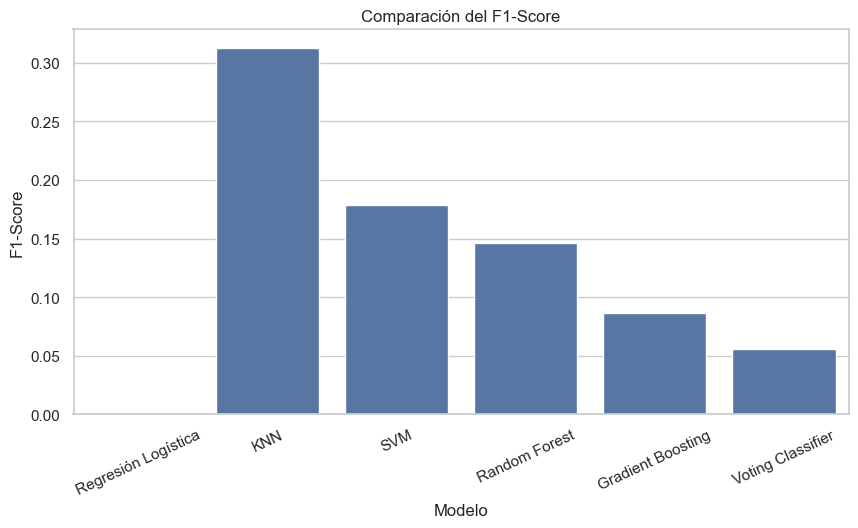

In [85]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=resultados,

    x="Modelo",

    y="F1-Score"

)

plt.xticks(rotation=25)

plt.title("Comparación del F1-Score")

plt.show()

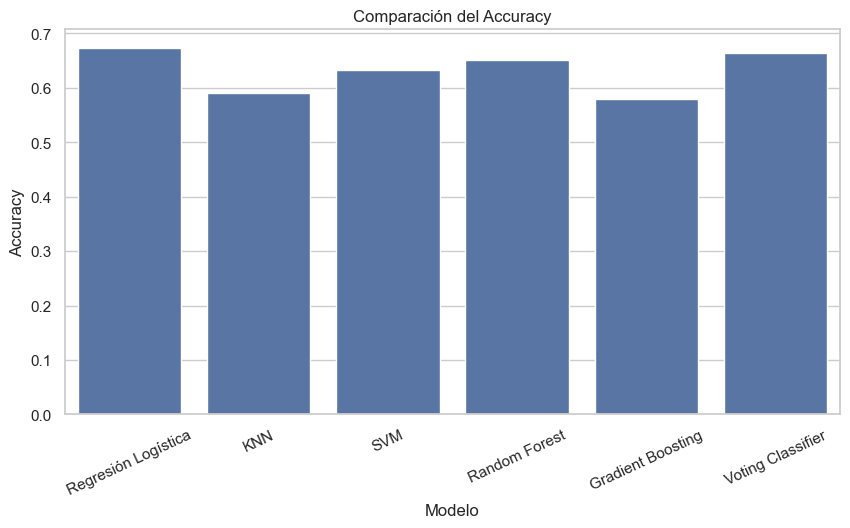

In [86]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=resultados,

    x="Modelo",

    y="Accuracy"

)

plt.xticks(rotation=25)

plt.title("Comparación del Accuracy")

plt.show()

## Interpretación

La comparación de métricas permite identificar cuál de los modelos ofrece el mejor equilibrio entre precisión y capacidad de generalización.

En problemas relacionados con la predicción del abandono de clientes, el **F1-Score** constituye una métrica especialmente importante, ya que combina precisión y sensibilidad, evitando favorecer únicamente a la clase mayoritaria.

# Comparación de Curvas ROC

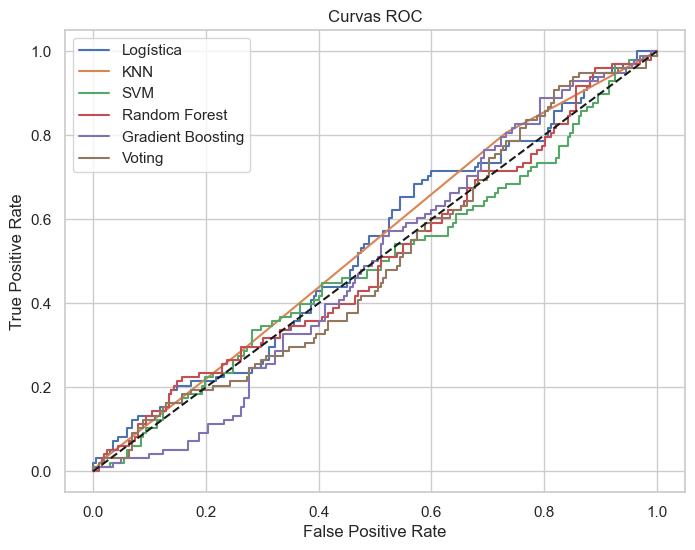

In [87]:
plt.figure(figsize=(8,6))

modelos = [

    ("Logística",prob_lr),

    ("KNN",prob_knn),

    ("SVM",prob_svc),

    ("Random Forest",prob_rf),

    ("Gradient Boosting",prob_gb),

    ("Voting",prob_voting)

]

for nombre,prob in modelos:

    fpr,tpr,_=roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=nombre)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curvas ROC")

plt.legend()

plt.show()

# Importancia de las variables

Uno de los modelos que permite interpretar la influencia de cada variable es Random Forest.

A continuación se muestran las variables con mayor importancia para la predicción del abandono.

In [88]:
ohe = modelo_rf.named_steps["preprocesamiento"] \
               .named_transformers_["cat"] \
               .named_steps["onehot"]

variables_finales = (

    variables_numericas +

    list(ohe.get_feature_names_out(variables_categoricas))

)

In [89]:
importancias = modelo_rf.named_steps["modelo"].feature_importances_

imp = pd.DataFrame({

    "Variable":variables_finales,

    "Importancia":importancias

})

imp = imp.sort_values(

    by="Importancia",

    ascending=False

)

imp.head(10)

,Variable,Importancia
3,gasto_promedio_cita,0.150701
6,gasto_total_anual,0.147247
1,ingreso_mensual,0.145384
5,recencia_dias,0.141816
4,antiguedad_meses,0.127402
0,edad,0.114110
2,frecuencia_citas,0.085752
7,num_condiciones_cronicas,0.032462
12,canal_atencion_Telemedicina,0.015951
11,canal_atencion_Presencial,0.014454


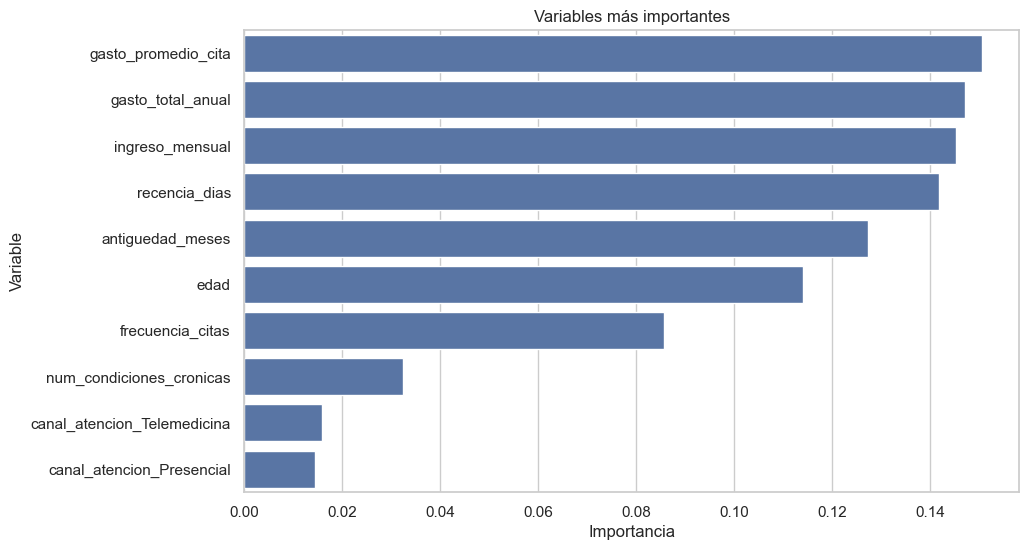

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=imp.head(10),

    x="Importancia",

    y="Variable"

)

plt.title("Variables más importantes")

plt.show()

### Interpretación

Las variables con mayor importancia representan los factores que más contribuyen a la predicción del abandono.

En el contexto de VidaCare Perú, variables como la frecuencia de citas, la recencia de atención, la antigüedad y el tipo de plan contratado constituyen indicadores relevantes para identificar pacientes con mayor riesgo de abandonar la plataforma.

# Selección del modelo final

In [91]:
mejor = resultados.sort_values(

    by="F1-Score",

    ascending=False

).iloc[0]

mejor

Modelo            KNN
Accuracy         0.59
Precision    0.345679
Recall       0.285714
F1-Score     0.312849
ROC-AUC      0.536826
Name: 1, dtype: object

## Justificación

El modelo seleccionado corresponde al algoritmo que obtuvo el mayor F1-Score durante la evaluación.

La elección de esta métrica se debe a que el problema de abandono presenta dos clases y resulta importante equilibrar la capacidad para identificar correctamente pacientes que abandonarán la plataforma sin generar un número excesivo de falsas alarmas.

Este modelo será el recomendado para su implementación dentro de VidaCare Perú como herramienta de apoyo para campañas de retención de pacientes.

# Conclusiones

1. Fue posible desarrollar un modelo de clasificación supervisada capaz de predecir el abandono de pacientes utilizando información demográfica, económica y de comportamiento.

2. El proceso de preprocesamiento permitió tratar adecuadamente valores faltantes y preparar los datos para los distintos algoritmos evaluados.

3. Los modelos de ensamble, como Random Forest, Gradient Boosting y Voting Classifier, mostraron un rendimiento competitivo gracias a su capacidad para capturar relaciones complejas entre las variables.

4. La comparación de métricas permitió seleccionar el modelo con mejor equilibrio entre precisión y sensibilidad, siendo el más adecuado para apoyar estrategias de fidelización de pacientes.

5. La implementación de este tipo de modelos permitirá a VidaCare Perú identificar tempranamente pacientes con riesgo de abandono y diseñar campañas preventivas más efectivas, mejorando la retención de clientes y optimizando los recursos destinados a marketing.

# Registro de Prompts Utilizados

En el desarrollo del Informe 4 se utilizó ChatGPT como herramienta de apoyo para resolver dudas puntuales relacionadas con la implementación de modelos de clasificación, interpretación de resultados y buenas prácticas en Machine Learning. Todos los resultados obtenidos fueron revisados, adaptados y validados por el equipo antes de incorporarlos al informe.

| Objetivo | Herramienta | Prompt utilizado | Resultado obtenido | Validación realizada |
|----------|-------------|------------------|-------------------|---------------------|
| Selección de modelos | ChatGPT | ¿Qué modelos de clasificación supervisada son adecuados para predecir una variable binaria como **abandono** en un dataset de pacientes y cuáles recomienda la documentación de scikit-learn para compararlos? | Se obtuvo una recomendación de utilizar Regresión Logística, KNN, SVM, Random Forest y Gradient Boosting, complementando el análisis con un modelo de ensamble. | Se verificó que los modelos cumplen con los requisitos del proyecto y con la bibliografía del curso. |
| Preprocesamiento | ChatGPT | Mi dataset contiene variables numéricas, categóricas y algunos valores nulos. ¿Cuál sería un flujo adecuado de preprocesamiento antes de entrenar modelos de clasificación en scikit-learn? | Se obtuvo una propuesta de imputación de datos, codificación One-Hot, escalamiento de variables numéricas y uso de Pipeline con ColumnTransformer. | El flujo fue implementado y probado correctamente con el dataset de VidaCare Perú. |
| Ajuste de hiperparámetros | ChatGPT | ¿Qué hiperparámetros básicos conviene optimizar mediante GridSearchCV para Regresión Logística, KNN, SVM, Random Forest y Gradient Boosting? | Se obtuvieron sugerencias de hiperparámetros para cada algoritmo y ejemplos de búsqueda mediante GridSearchCV. | Los rangos fueron adaptados al problema y evaluados mediante validación cruzada. |
| Evaluación del modelo | ChatGPT | ¿Qué métricas son más apropiadas para evaluar un problema de clasificación binaria orientado a predecir abandono de clientes y cómo se interpretan? | Se explicó el uso de Accuracy, Precision, Recall, F1-Score, ROC-AUC y la matriz de confusión. | Las métricas se calcularon directamente con scikit-learn y fueron comparadas entre todos los modelos. |
| Interpretación de resultados | ChatGPT | ¿Cómo interpretar la importancia de variables obtenida con Random Forest dentro del contexto de una empresa de salud digital? | Se obtuvo una explicación de cómo relacionar las variables más importantes con el comportamiento de los pacientes. | La interpretación fue contrastada con el contexto de VidaCare Perú y con los resultados del análisis exploratorio. |
| Redacción de conclusiones | ChatGPT | Ayúdame a mejorar la redacción de las conclusiones del informe manteniendo un lenguaje académico y relacionándolas con el problema de negocio. | Se obtuvieron sugerencias de redacción que posteriormente fueron adaptadas por el equipo al informe final. | Se revisó que las conclusiones reflejaran únicamente los resultados obtenidos durante la experimentación. |